In [1]:
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import euclidean
from collections import defaultdict

In [3]:
# Load the dataset
file_path = 'E:\sigai\seperate-data\merged_dataset.csv'
data = pd.read_csv(file_path)

# Convert the datetime column to a datetime object
data['datetime'] = pd.to_datetime(data['datetime'])

# Define the function to assign buckets
def assign_bucket(row):
    time = row['datetime'].time()
    if time >= pd.Timestamp('00:10').time() and time < pd.Timestamp('08:10').time():
        return '00:10 - 08:10'
    elif time >= pd.Timestamp('08:10').time() and time < pd.Timestamp('16:10').time():
        return '08:10 - 16:10'
    else:
        return '16:10 - 00:10'

# Assign buckets to each row
data['bucket'] = data.apply(assign_bucket, axis=1)
data['index'] = (data['bucket'] != data['bucket'].shift()).cumsum()
data.loc[data['index'] > 1, 'index'] = data['index'] - 1

# Save the bucketed data to a new CSV file
output_path = 'E:\sigai\\bucketed_dataset.csv'
data.to_csv(output_path, index=False)


In [2]:
# Load the dataset
file_path = 'E:\sigai\jan_feb_2024_subset.csv'
df = pd.read_csv(file_path)

# Convert datetime column to pandas datetime
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)
df.sort_index(ascending=True, inplace=True)

To perform Dynamic Time Warping (DTW) and cluster the indexes using agglomerative clustering, we'll follow these steps:

Calculate DTW distances between the sequences corresponding to each index.
Perform agglomerative clustering using these DTW distances.
Here's a detailed approach:

Extract sequences for each index.
Compute the DTW distance matrix.
Apply agglomerative clustering on the DTW distance matrix.
Let's start with implementing these steps.

Extract sequences for each index: Create a dictionary where each key is an index and the value is the sequence of sigai values corresponding to that index.

Compute the DTW distance matrix: Calculate the pairwise DTW distances between all sequences.

Apply agglomerative clustering on the DTW distance matrix: Use the distance matrix as input for hierarchical clustering.

In [3]:
# Extract sequences based on 'index'
sequences = defaultdict(list)
for _, row in df.iterrows():
    sequences[row['index']].append(row['sigai'])

# Convert sequences dictionary to a list of sequences
sequence_list = list(sequences.values())

# Normalize sequences
scaler = StandardScaler()
standardized_sequences = [scaler.fit_transform(np.array(seq).reshape(-1, 1)).flatten() for seq in sequence_list]

In [ ]:
# Compute Dynamic Time Warping (DTW) distance matrix
def dtw_distance(seq1, seq2):
    n, m = len(seq1), len(seq2)
    dtw_matrix = np.zeros((n+1, m+1)) + float('inf')
    dtw_matrix[0, 0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(seq1[i-1] - seq2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match

    return dtw_matrix[n, m]

num_sequences = len(standardized_sequences)
distance_matrix = np.zeros((num_sequences, num_sequences))

for i in range(num_sequences):
    for j in range(i + 1, num_sequences):
        distance = dtw_distance(standardized_sequences[i], standardized_sequences[j])
        distance_matrix[i, j] = distance
        distance_matrix[j, i] = distance

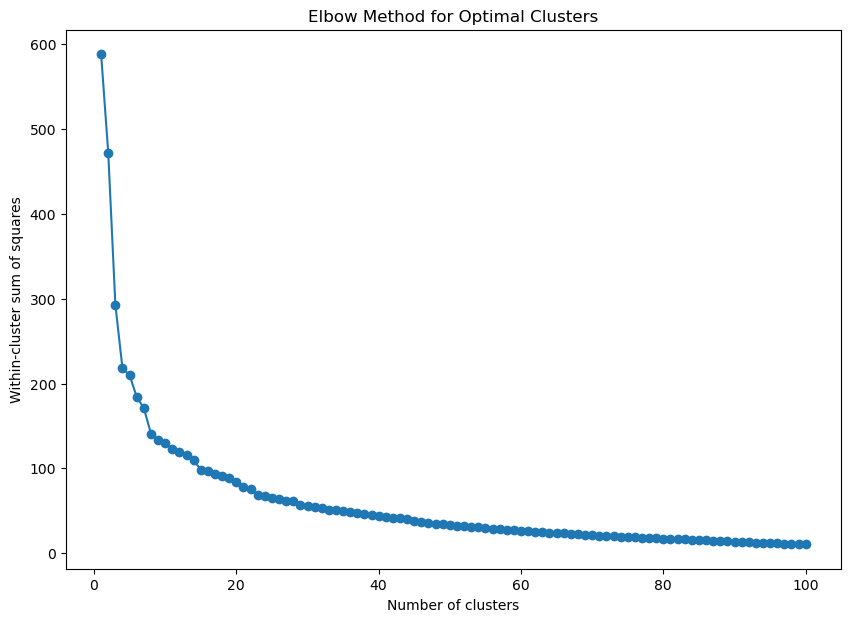

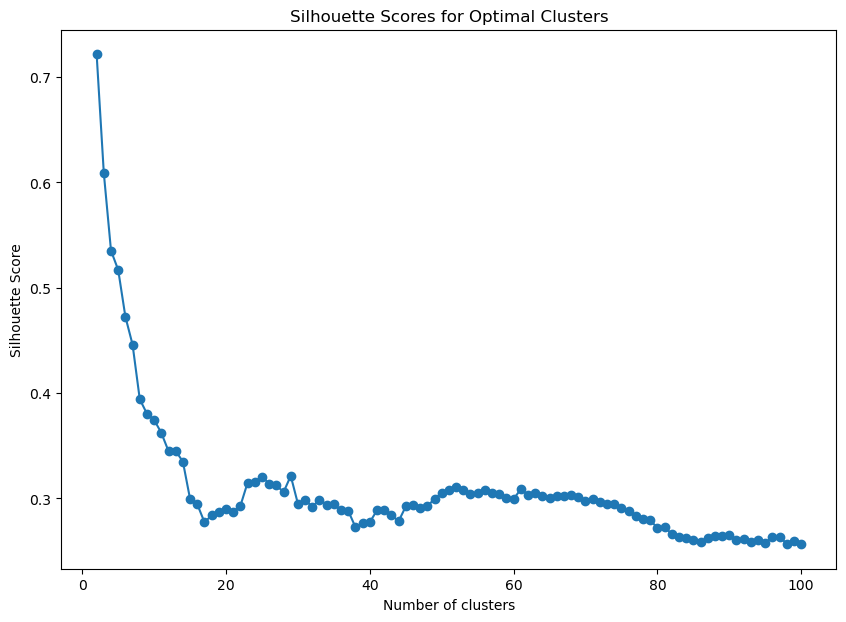

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score

# Function to compute the within-cluster sum of squares (WCSS)
def compute_wcss(linkage_matrix, distance_matrix, max_clusters):
    wcss = []
    for num_clusters in range(1, max_clusters + 1):
        clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
        sum_of_squares = 0
        for cluster_id in np.unique(clusters):
            cluster_points = np.where(clusters == cluster_id)[0]
            intra_cluster_dists = distance_matrix[np.ix_(cluster_points, cluster_points)]
            sum_of_squares += np.sum(intra_cluster_dists) / len(cluster_points)
        wcss.append(sum_of_squares)
    return wcss

# Function to compute the silhouette scores
def compute_silhouette_scores(distance_matrix, linkage_matrix, max_clusters):
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        clusters = fcluster(linkage_matrix, num_clusters, criterion='maxclust')
        silhouette_avg = silhouette_score(distance_matrix, clusters, metric='precomputed')
        silhouette_scores.append(silhouette_avg)
    return silhouette_scores

# Generate linkage matrix
linkage_matrix = linkage(squareform(dtw_distances), method='complete')

# Compute WCSS for different numbers of clusters
max_clusters = 100  # You can adjust this value based on your data
wcss = compute_wcss(linkage_matrix, dtw_distances, max_clusters)

# Plot the Elbow Method
plt.figure(figsize=(10, 7))
plt.plot(range(1, max_clusters + 1), wcss, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Within-cluster sum of squares')
plt.show()

# Compute Silhouette scores for different numbers of clusters
silhouette_scores = compute_silhouette_scores(dtw_distances, linkage_matrix, max_clusters)

# Plot Silhouette scores
plt.figure(figsize=(10, 7))
plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal Clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()
